<a href="https://colab.research.google.com/github/ealger22/main/blob/CSC-302-Data-Visualization/FacetGrid_ICA_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive




*   Please read titanic.csv from the DATA folder
*   Change 1s to "Survived" under the Survived column of the data frame by looking at the example provided.
*   Get rows which don't have "?" under Pclass column and move to the next step.




In [16]:
import pandas as pd

# Load the Titanic dataset
titanic = pd.read_csv('/content/drive/MyDrive/ColabFiles/titanic.csv')

# Convert 'Survived' column to string before replacing values
titanic["Survived"] = titanic["Survived"].astype(str)
titanic.loc[titanic["Survived"] == "1", "Survived"] = "Survived"

# Filter out rows where Pclass is "?"
titanic = titanic[titanic["Pclass"] != "?"]


Create a multipanel plot which draws density plots for each class-survived combination. Please also use the hue parameter based on the Sex attribute to have two density plots in each panel with different colors.

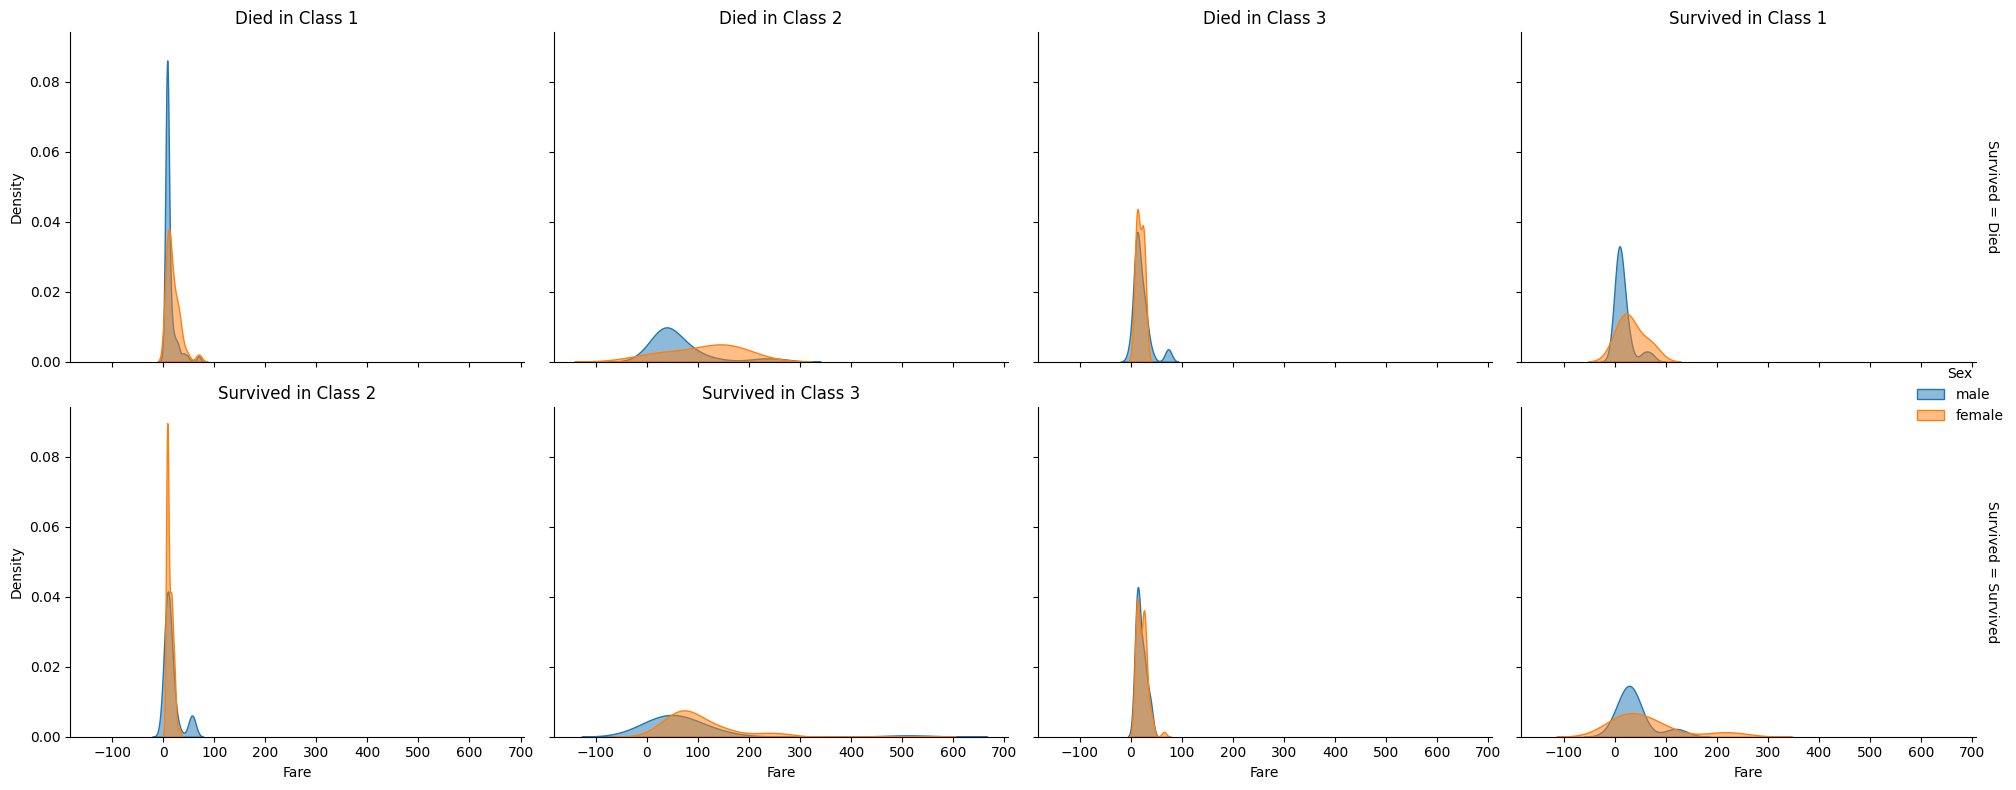

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Titanic dataset
titanic = pd.read_csv('/content/drive/MyDrive/ColabFiles/titanic.csv')  # adjust path as needed

# Step 2: Clean up the 'Survived' column to use labels instead of numbers
titanic["Survived"] = titanic["Survived"].astype(str)
titanic.loc[titanic["Survived"] == "0", "Survived"] = "Died"
titanic.loc[titanic["Survived"] == "1", "Survived"] = "Survived"

# Step 3: Drop rows with missing required data
titanic = titanic.dropna(subset=["Pclass", "Fare", "Sex"])

# Step 4: Create a Seaborn FacetGrid to organize plots by Survived (row) and Pclass (column)
g = sns.FacetGrid(
    data=titanic,
    row="Survived",
    col="Pclass",
    hue="Sex",               # this will create separate lines by sex
    height=4,
    aspect=1.2,
    margin_titles=True
)

# Step 5: Draw the KDE plots (density of Fare) for each panel
g.map(sns.kdeplot, "Fare", fill=True, alpha=0.5, warn_singular=False)

# Step 6: Add legend for the hue
g.add_legend(title="Sex")

# Step 7: (Optional) Set titles for clarity
titles = [
    'Died in Class 1', 'Died in Class 2', 'Died in Class 3',
    'Survived in Class 1', 'Survived in Class 2', 'Survived in Class 3'
]
for ax, title in zip(g.axes.flatten(), titles):
    ax.set_title(title)

# Step 8: Final layout adjustment
plt.tight_layout()
plt.show()


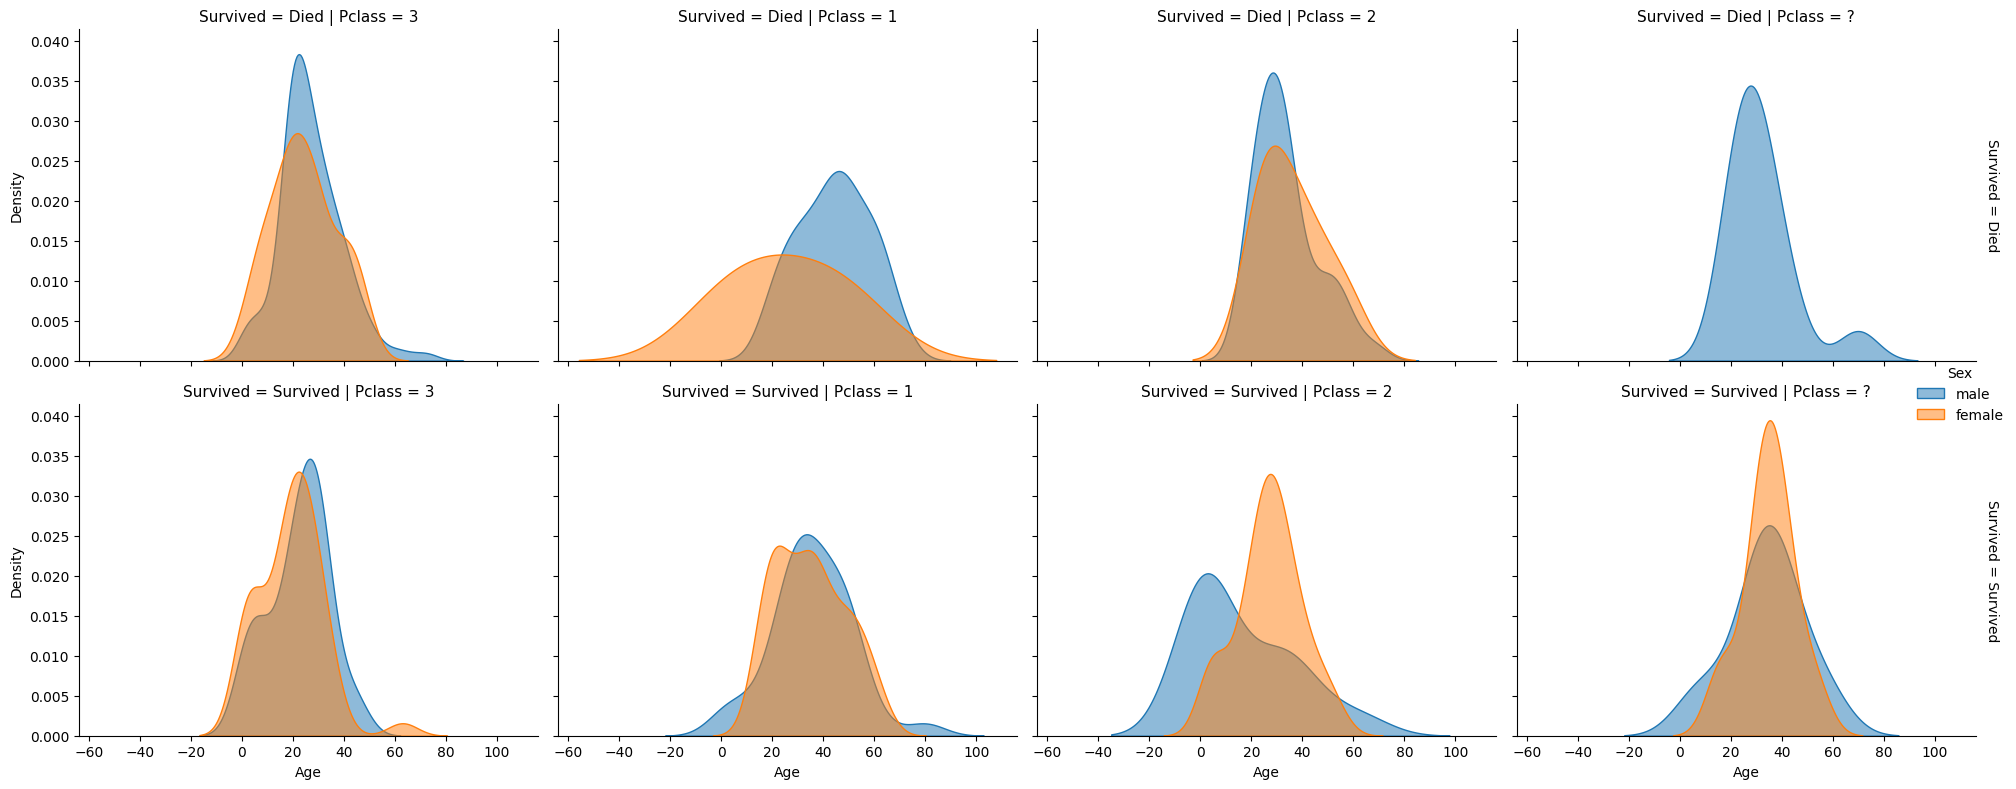

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
titanic = pd.read_csv('/content/drive/MyDrive/ColabFiles/titanic.csv')

# Convert 'Survived' to string and relabel
titanic["Survived"] = titanic["Survived"].astype(str)
titanic.loc[titanic["Survived"] == "0", "Survived"] = "Died"
titanic.loc[titanic["Survived"] == "1", "Survived"] = "Survived"

# Drop rows with missing values
titanic = titanic.dropna(subset=["Pclass", "Age", "Sex"])

# Create FacetGrid
g = sns.FacetGrid(
    data=titanic,
    row="Survived",
    col="Pclass",
    hue="Sex",
    height=4,
    aspect=1.2,
    margin_titles=True
)

# Map KDE plots
g.map(sns.kdeplot, "Age", fill=True, alpha=0.5, warn_singular=False)
g.add_legend(title="Sex")

# Set subplot titles dynamically
for (row_val, col_val), ax in g.axes_dict.items():
    ax.set_title(f"Survived = {row_val} | Pclass = {col_val}", fontsize=11)

plt.tight_layout()
plt.show()

# -------------------------
# Comments Section:
# -------------------------
# - Converted 'Survived' column to string before replacing values to avoid dtype warnings.
# - Dropped missing values from Age, Sex, and Pclass to avoid empty or skipped plots.
# - Used warn_singular=False to suppress density warnings when group variance is zero.
# - Used FacetGrid axes_dict to set titles like "Survived = ... | Pclass = ..." to match example.
